# Conhecendo o conjunto de dados

I - Importar as bibliotecas.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

II - Carregar o arquivo CSV.

In [2]:
df = pd.read_csv("Melhores_filmes_e_séries_de_TVIMDb.csv")

III - Exibir as primeiras e últimas linhas.

In [3]:
df.head()

,title,titleType,genres,numVotes,year,averageRating
0,The Shawshank Redemption,movie,Drama,3185932,1994,9.3
1,The Dark Knight,movie,"Action,Crime,Drama",3165032,2008,9.1
2,Inception,movie,"Action,Adventure,Sci-Fi",2814573,2010,8.8
3,Game of Thrones,tvSeries,"Action,Adventure,Drama",2611980,2011,9.2
4,Breaking Bad,tvSeries,"Crime,Drama,Thriller",2611328,2008,9.5


In [4]:
df.tail()

,title,titleType,genres,numVotes,year,averageRating
9994,Blood & Gold,movie,"Action,Drama,War",20178,2023,6.5
9995,Santa Claus Is Comin' to Town,tvMovie,"Adventure,Animation,Comedy",20176,1970,7.7
9996,The Tonight Show Starring Jimmy Fallon,tvSeries,"Comedy,Music,Talk-Show",20176,2014,7.0
9997,Come Play,movie,"Drama,Horror,Mystery",20172,2020,5.8
9998,Holiday,movie,"Comedy,Romance",20171,1938,7.7


IV - Identificar o número de linhas e colunas.

In [5]:
df.shape

(9999, 6)

V - Verificar os tipos de dados de cada coluna.

In [6]:
df.dtypes

title                str
titleType            str
genres               str
numVotes           int64
year               int64
averageRating    float64
dtype: object

Alteração nos nomes das colunas e criação de um  novo dataframe que tem os nomes das colunas em português.

In [7]:
df_renomeado = df.rename(columns={
    'title':'Titulo', 
    'titleType':'Categoria', 
    'genres':'Generos', 
    'numVotes':'Numero_Votos', 
    'year':'Ano', 
    'averageRating':'Media_Avaliacao'
})

In [8]:
df_renomeado.head()

,Titulo,Categoria,Generos,Numero_Votos,Ano,Media_Avaliacao
0,The Shawshank Redemption,movie,Drama,3185932,1994,9.3
1,The Dark Knight,movie,"Action,Crime,Drama",3165032,2008,9.1
2,Inception,movie,"Action,Adventure,Sci-Fi",2814573,2010,8.8
3,Game of Thrones,tvSeries,"Action,Adventure,Drama",2611980,2011,9.2
4,Breaking Bad,tvSeries,"Crime,Drama,Thriller",2611328,2008,9.5


# Qualidade dos dados

I - Verificar valores nulos.

In [9]:
print(df_renomeado.isnull().sum())

np.where(df.isnull())

Titulo             0
Categoria          0
Generos            1
Numero_Votos       0
Ano                0
Media_Avaliacao    0
dtype: int64


(array([4841]), array([2]))

II - Verificar valores duplicados.

In [23]:
print(df_renomeado.duplicated().sum())

0


III - Identificar possíveis inconsistências.

In [24]:
print(df_renomeado[df_renomeado["Numero_Votos"] < 0], "\n")
print(df_renomeado[(df_renomeado["Media_Avaliacao"] < 0) | (df_renomeado["Media_Avaliacao"] > 10)], "\n")
print(df_renomeado["Categoria"].unique(), "\n")
print(df_renomeado["Generos"].unique(), "\n")

Empty DataFrame
Columns: [Titulo, Categoria, Generos, Numero_Votos, Ano, Media_Avaliacao]
Index: [] 

Empty DataFrame
Columns: [Titulo, Categoria, Generos, Numero_Votos, Ano, Media_Avaliacao]
Index: [] 

<StringArray>
[       'movie',     'tvSeries', 'tvMiniSeries',    'tvSpecial',
      'tvMovie',        'video',    'videoGame',        'short',
      'tvShort']
Length: 9, dtype: str 

<StringArray>
[                   'Drama',       'Action,Crime,Drama',
  'Action,Adventure,Sci-Fi',   'Action,Adventure,Drama',
     'Crime,Drama,Thriller',   'Adventure,Drama,Sci-Fi',
            'Drama,Romance',              'Crime,Drama',
            'Action,Sci-Fi',  'Adventure,Drama,Fantasy',
 ...
   'Family,Fantasy,Musical',     'Comedy,Crime,History',
  'Drama,Horror,Reality-TV',    'Crime,Sci-Fi,Thriller',
    'Action,Horror,Romance',      'Comedy,Horror,Music',
             'Action,Short',  'Crime,Documentary,Sport',
 'Animation,Fantasy,Horror',    'Action,Horror,Western']
Length: 466, dtype: st

IV - Realizar a limpeza, se necessário.

In [25]:
#substituir o valor nulo por um texto
df_renomeado["Generos"] = df_renomeado["Generos"].fillna("Desconhecido")

print(df_renomeado.isnull().sum())

Titulo             0
Categoria          0
Generos            0
Numero_Votos       0
Ano                0
Media_Avaliacao    0
dtype: int64


# Estatísticas descritivas

In [29]:
print("Principais estatísticas\n", df_renomeado[["Numero_Votos", "Media_Avaliacao"]].describe(), "\n")

print("Média:")
print(f"Número de votos: {np.mean(df_renomeado["Numero_Votos"])}\n")

print(f"Mediana:")
print(f"Número de votos: {np.median(df_renomeado["Numero_Votos"])}")
print(f"Ano: {np.median(df_renomeado["Ano"])}")
print(f"Média de avaliações: {np.median(df_renomeado["Media_Avaliacao"])}\n")


Principais estatísticas
        Numero_Votos  Media_Avaliacao
count  9.999000e+03      9999.000000
mean   1.215959e+05         6.849405
std    2.002060e+05         1.046733
min    2.017100e+04         1.000000
25%    3.065550e+04         6.200000
50%    5.417300e+04         6.900000
75%    1.228770e+05         7.600000
max    3.185932e+06         9.800000 

Média:
Número de votos: 121595.92139213921

Mediana:
Número de votos: 54173.0
Ano: 2010.0
Média de avaliações: 6.9



# Visualização dos dados

- Quantidade de produções por categoria

      Categoria  Quantidade
0         movie        8208
1      tvSeries        1326
2  tvMiniSeries         245
3         video          86
4       tvMovie          46
5     videoGame          40
6         short          35
7     tvSpecial          11
8       tvShort           2


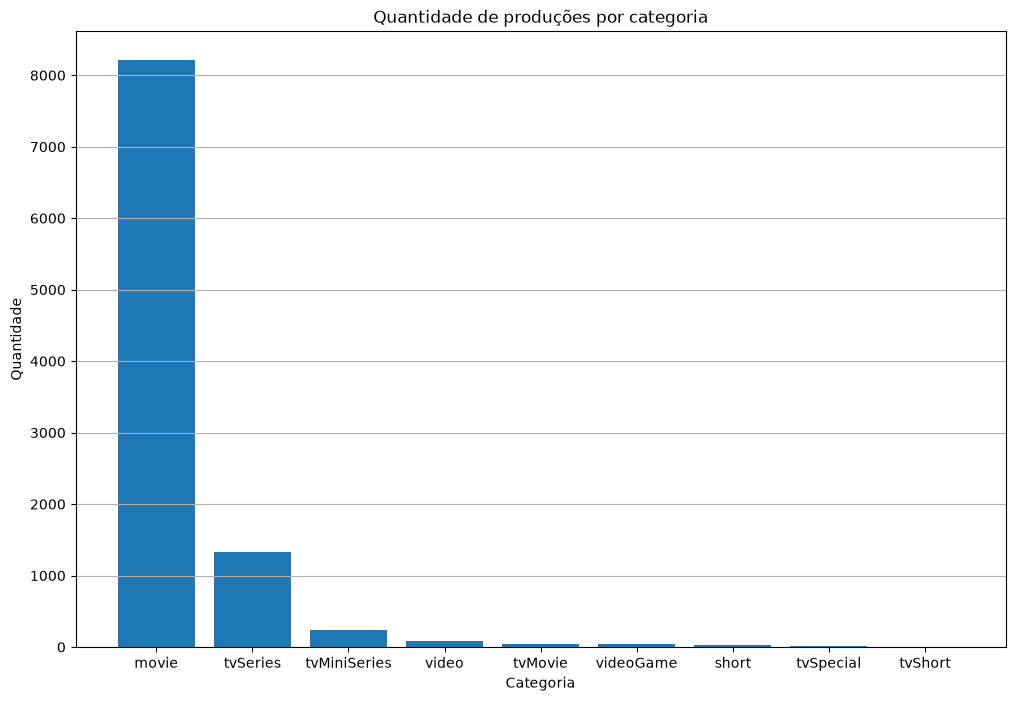

In [14]:
#Gráfico de barras(bar)
qtd_categoria = df_renomeado["Categoria"].value_counts()
qtd_categoria = qtd_categoria.reset_index()
qtd_categoria = qtd_categoria.rename(columns={'count':'Quantidade'})
print(qtd_categoria)

plt.figure(figsize=(12, 8))
plt.bar(qtd_categoria["Categoria"], qtd_categoria["Quantidade"])
plt.title("Quantidade de produções por categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.grid(axis="y")
plt.show()

Pode ser observado que há uma discrepância entre as categorias, aquela que mais tem produção é filmes.

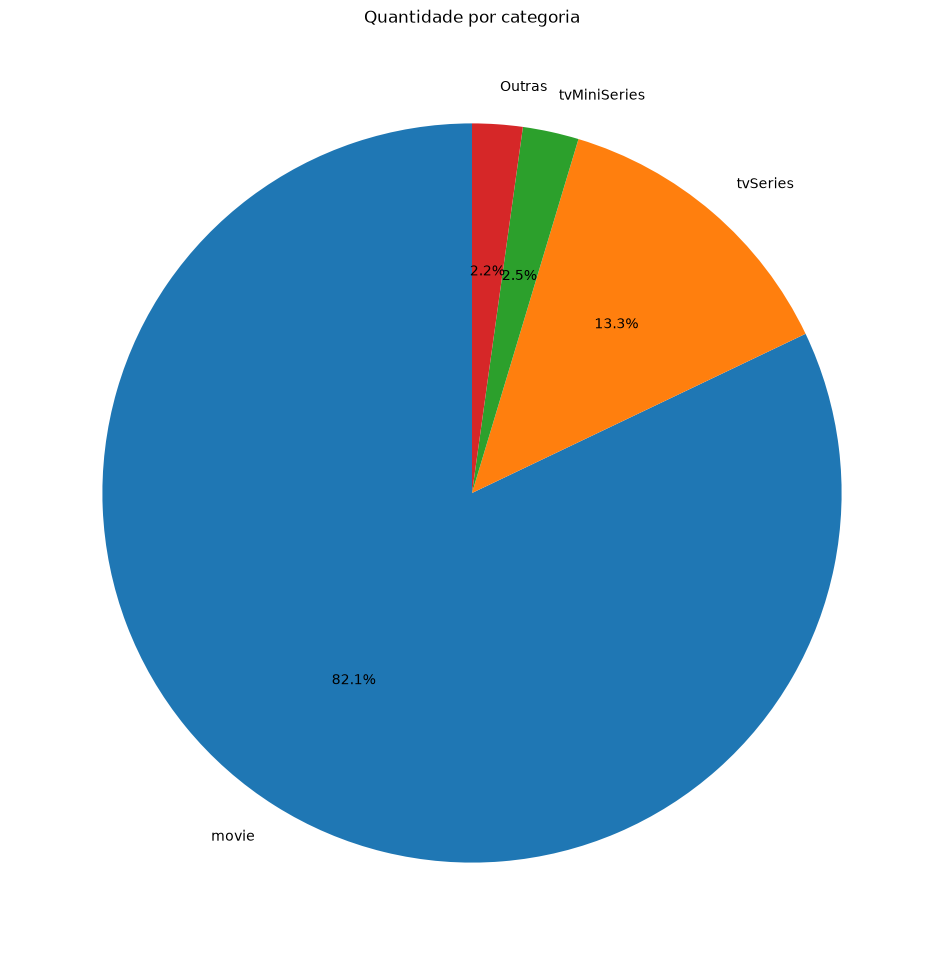

In [15]:
qtd_categoria["Porcentagem"] = (qtd_categoria["Quantidade"] / qtd_categoria["Quantidade"].sum()) * 100

principais = qtd_categoria[qtd_categoria["Porcentagem"] >= 2].copy()
pequenos = qtd_categoria[qtd_categoria["Porcentagem"] < 2].copy()

linha_outras = pd.DataFrame({
    'Categoria': ['Outras'],
    'Quantidade': [pequenos["Quantidade"].sum()]
})
    
df_grafico = pd.concat([principais[['Categoria', 'Quantidade']], linha_outras], ignore_index=True)

plt.figure(figsize=(12, 12))

plt.pie(
    df_grafico["Quantidade"],
    labels= df_grafico["Categoria"],
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Quantidade por categoria")
plt.show()

Para complementar apresento o gráfico de pizza de quantidade por categoria, assim conseguimos visualizar o percentual de cada categoria. Há o percentual das 3 maiores categorias, e as demais categorias, que apresentaram um percentual de menos de 2%, estão agrupadas na categoria outras.

- Quantidade de produções por década

Ano da produção mais recente: 2026
Ano da produção mais antiga: 1902 

Ano
1900-1909       2
1910-1919       1
1920-1929      15
1930-1939      42
1940-1949      80
1950-1959     129
1960-1969     203
1970-1979     303
1980-1989     646
1990-1999    1202
2000-2009    2322
2010-2019    3274
2020-2029    1780
Name: count, dtype: int64


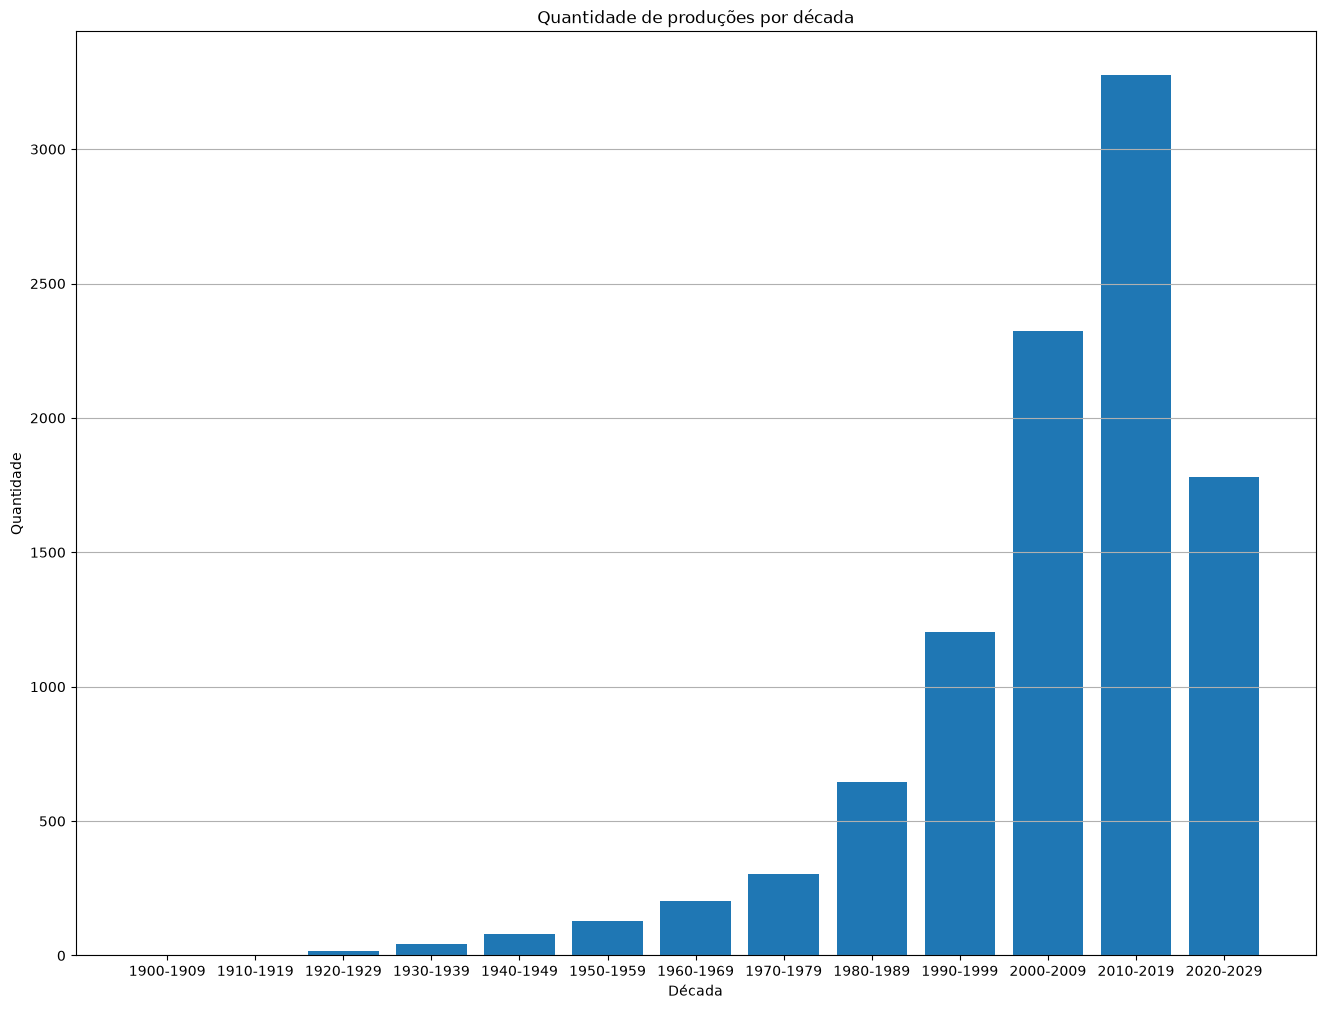

In [34]:
#Gráfico de barras(bar)
print("Ano da produção mais recente:", df_renomeado["Ano"].max())
print("Ano da produção mais antiga:", df_renomeado["Ano"].min(), '\n')

decada = (df_renomeado["Ano"] // 10) * 10
decada_rotulo = decada.astype(str) + "-" + (decada + 9).astype(str)

qtd_por_decada = decada_rotulo.value_counts().sort_index()
print(qtd_por_decada)

plt.figure(figsize=(16, 12))
plt.bar(qtd_por_decada.index, qtd_por_decada.values)
plt.title("Quantidade de produções por década")
plt.xlabel("Década")
plt.ylabel("Quantidade")
plt.grid(axis="y")
plt.show()

Ao longo das décadas percebe-se que houve um crescimento nas produções. Além disso, durante a década de 2010-2019 teve a maior qantidade de produções. Na década de 2020-2029 só há produções até o ano de 2026, mesmo assim a quantidade de produções até este ano levou a chegar em mais da metade da quantidade de produções em comparação com a década anterior. 

- Quantidade de produções por gênero

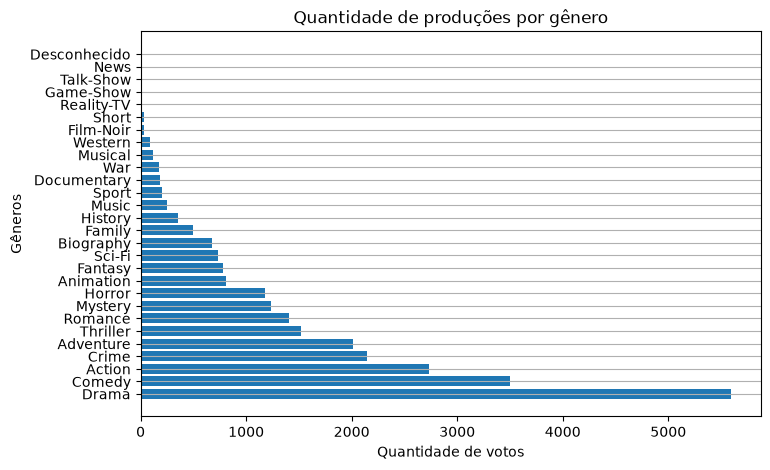

In [ ]:
#Gráfico de barras horizontal(barh)
generos = df_renomeado["Generos"]

#divide os generos pela vírgula, de forma que cada tupla terá uma array de generos
generos = generos.str.split(",")

#destrincha cada array de cada tupla em linhas
generos = generos.explode()

#retira espaços em brancos se houver
generos = generos.str.strip()

qtd_generos = generos.value_counts()

#alterar o tamanho da fonte dos textos dos gêneros
#alterar o tamanho das barras
plt.figure(figsize=(8, 5))
plt.barh(qtd_generos.index, qtd_generos.values)
plt.xlabel("Quantidade de votos")
plt.ylabel("Gêneros")
plt.title("Quantidade de produções por gênero")
plt.grid(axis="y")
plt.show()

Quanto a quantidade de produções por gêneros temos que drama, comédia e ação são os gêneros que mais se destacaram, com a maior quantidade sendo de drama, havendo uma discrepância enorme entre drama e as demais categorias, considerando o período de 1902 até 2026.

- Quantidade de votos por gênero

In [ ]:
#gráfico de barrass horizontal(barh)

- Quantidade de votos por categoria

In [ ]:
#gráfico de barras(bar)

- Quantidade de votos por ano ou década

In [ ]:
#gráfico de barras(bar)

- Média de avaliações

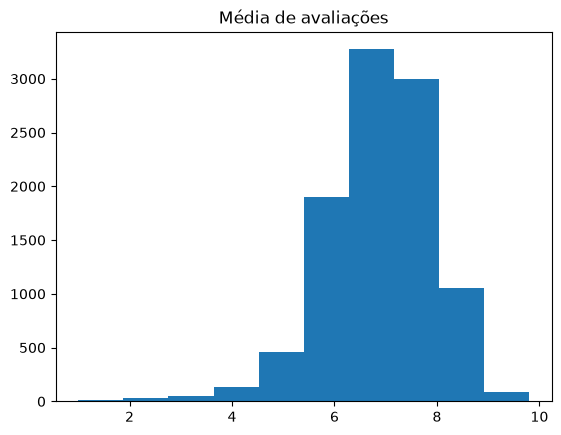

In [18]:
#Gráfico de histograma(hist)
plt.hist(df_renomeado["Media_Avaliacao"])
plt.title("Média de avaliações")
plt.show()

Quanto a distribuição das médias de avaliações, tem-se que há poucas avaliações baixas e também poucas avaliações de 9 à 10. Percebe-se que as médias de avaliações estão centradas no intervalo de 6 à 8, em que as maiores quantidades está entre 7 e 8.

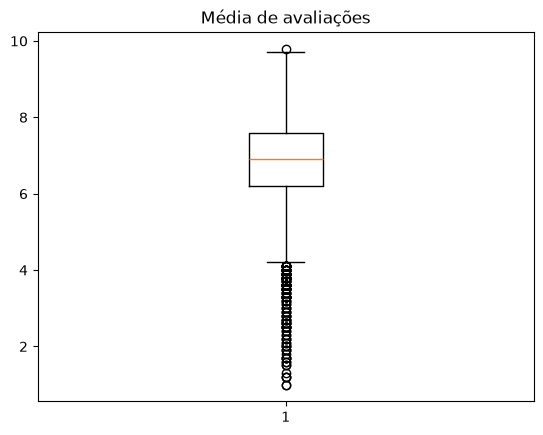

In [19]:
plt.boxplot(df_renomeado["Media_Avaliacao"])
plt.title("Média de avaliações")
plt.show()


Com o auxílio deste boxplot percebe-se que há valores extremos nas médias de avaliações, principalmente na parte inferior, dentre as avaliações de 1 à 4. Além disso, há apenas um extremo na parte superior.

In [ ]:
#criar um boxplot de quantidade de votos

- Média de avaliações por ano

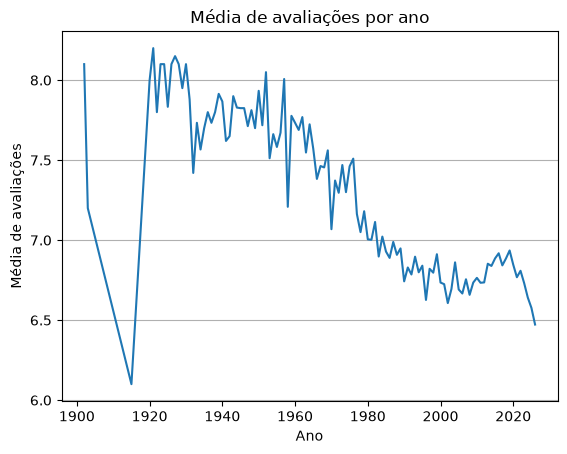

In [20]:
#Gráfico de linhas(plot)
media_por_ano = (
    df_renomeado.groupby("Ano")["Media_Avaliacao"]
    .mean()
    .reset_index()
)

plt.plot(media_por_ano["Ano"], media_por_ano["Media_Avaliacao"])
plt.xlabel("Ano")
plt.ylabel("Média de avaliações")
plt.title("Média de avaliações por ano")
plt.grid(axis="y")
plt.show()

Há uma grande queda nas médias de avaliações de produções de 1900 à 1915. A partir de produções de 1915, há um grande crescimento das avaliações. Se trata de um gráfico decrescente, além de apresentar várias oscilações nas médias das produções de 1920 a 2026.

- Relação entre número de votos e média de avaliações 

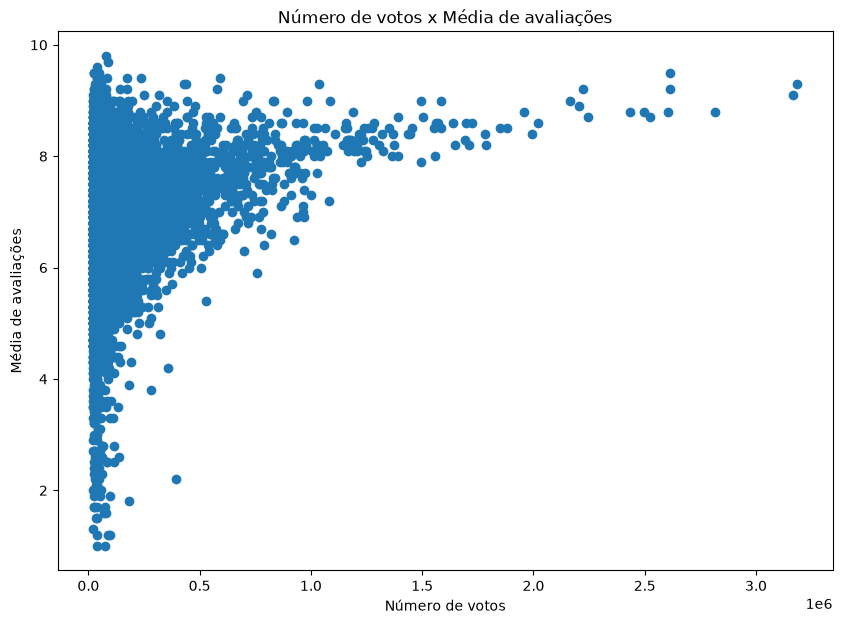

In [21]:
#Gráfico de dispersão(scatter)
plt.figure(figsize=(10,7))
plt.scatter(df_renomeado["Numero_Votos"], df_renomeado["Media_Avaliacao"])
plt.title("Número de votos x Média de avaliações")
plt.xlabel("Número de votos")
plt.ylabel("Média de avaliações")
plt.show()

Existe alguma relação entre a quantidade de votos que uma produção recebe e sua média de avaliação?

Percebe-se que conforme o números de votos aumenta, os pontos estão centrados em médias de avaliações altas. Quando o número de votos estão baixos, os pontos variam entre avaliações baixas e altas. Ou seja, há uma tendência positiva conforme o número de votos aumenta.